In [64]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../../../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import pickle
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib
from matplotlib.lines import Line2D
from greedy_mis import min_greedy_mis, max_greedy_mis


matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (2 * 3.35, 3* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
def get_results(variation, p, runs, ns, iterations, version):

    MIS_size_list = []
    MIS_std_list = []

    for n in ns: 
        with open(f"../graphs/100_regular_graphs_nodes_{n}_reg_3_MIS_solutions.pkl", 'rb') as file:
            MIS_size_exact = pickle.load(file)

        MIS_size_list_n = []
        for run in runs:
            for iteration in iterations:
                try:
                    if variation == 'min_greedy':
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{1}_initialization_interpolation_variation_QIRO_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)
                        MIS_size_list_n.append(data['size_solution_min_greedy']/MIS_size_exact[run])       
                    elif variation == 'max_greedy':
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{1}_initialization_interpolation_variation_QIRO_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)
                        MIS_size_list_n.append(data['size_solution_max_greedy']/MIS_size_exact[run]) 
                    
                    else:
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{p}_initialization_interpolation_variation_{variation}_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)
                        if p==4:
                            MIS_size_list_n.append(data['size_solution_single']/MIS_size_exact[run])
                        else:
                            MIS_size_list_n.append(data['size_solution_qtensor']/MIS_size_exact[run])

                except Exception as error:
                    #print(error)
                    #print(f'file results_run_{run}_n_{n}_p_{p}_iteration_{iteration}_initialization_interpolation_variation_{variation}_version_{version}.pkl not available')
                    pass

        average = np.average(MIS_size_list_n)
        std = np.std(MIS_size_list_n)

        MIS_size_list.append(average)
        MIS_std_list.append(std)
    return MIS_size_list, MIS_std_list


### Linear

is happening
is happening
is happening


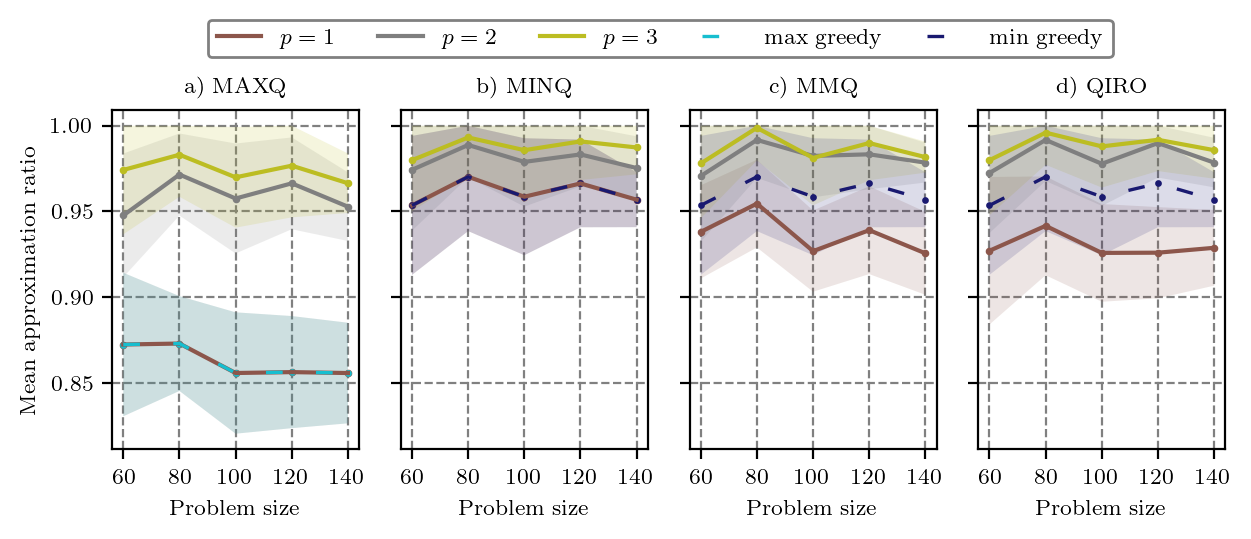

In [76]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
ps = [1, 2, 3]
runs = list(range(20))
variations = ['MAXQ', 'MINQ', 'MMQ', 'QIRO']
iterations = [0]
version = 4
ns = [60, 80, 100, 120, 140]#, 160]

major_yticks_pos = [0.8, 0.9, 0.95, 0.99]
major_yticks_names = [0.8, 0.9, 0.95, 0.99]
major_yticks_names_2 = [None for _ in range(len(major_yticks_pos))]
minor_yticks_pos = [0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.91, 0.92, 0.93, 0.94, 0.96, 0.97, 0.98]
minor_ticks_names = [None for _ in range(len(minor_yticks_pos))]

recalc_intervals = [1, 2, 10, 50, 100]
methods = [f'cycle+rec{i}' for i in recalc_intervals]+['cycle']
# labels = ['rec. interv. 1', 'rec. interv. 2','rec. interv. 5','rec. interv. 10','rec. interv. 50','rec. interv. $\infty$']
labels = ['$p = 1$', '$p = 2$', '$p = 3$', 'min greedy', 'max greedy']
fig, axs = plt.subplots(1, 4, dpi=200, layout='tight', figsize=(1.9 * 3.35, 1.3* 9 * 3.35 / 16), sharey='row')


for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
        
        mean, error = get_results(variations[idx], p, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1

    if idx ==0:
        counter +=1
        mean, error = get_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
    else:
        mean, error = get_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
    
        mean, error = get_results(variations[idx], p, runs, ns, iterations, version)
        mean = mean
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=3, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle='solid', linewidth=1.5, label=labels[counter], color=colors[counter+6])
        counter +=1
    
    if idx==0:
        counter +=1
        mean, error = get_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=1.2, label=labels[counter], color=colors[counter+6])
        counter +=1
    else:
        print('is happening')
        mean, error = get_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=1.2, label=labels[counter], color=colors[counter+6])
        counter +=1

for ax in axs:
    ax.set_xlabel('Problem size')
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    ax.set_axisbelow(True)
    ax.set_xticks(ns, ns)
   #ax.set_yscale('logit')
    #ax.set_ylim(bottom=0.79, top=0.995)



axs[0].set_ylabel('Mean approximation ratio')
#ax1.set_xticks(range(1, 17, 2), np.round(np.linspace(0.1, 0.80, 8), 2))
#ax1.set_xticks()
# ax1.set_yscale('logit')
axs[0].set_title('a) MAXQ', loc='center')
axs[1].set_title('b) MINQ', loc='center')
axs[2].set_title('c) MMQ', loc='center')
axs[3].set_title('d) QIRO', loc='center')
# #ax1.gca()
# ax1.yaxis.set_ticklabels([])
# ax1.set_ylim(bottom=0.79, top=0.9997)
#axs[0].set_yticks(major_yticks_pos, major_yticks_names)
#axs[0].set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)

plt.tight_layout()
lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = axs[1].get_legend_handles_labels()
lines.append(lines2[-1])
labels.append(labels2[-1])
axs[1].legend(lines, labels, loc='upper center', ncols=6, bbox_to_anchor=(1.05, 1.3), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)
#fig.savefig('./plots/appr_vs_density_log_gurobi_std_80_graphs_missing_errors.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Percental

In [68]:
def get_percental_results(variation, p, runs, ns, iterations, version):

    MIS_size_list = []
    MIS_std_list = []

    for n in ns: 
        with open(f"../graphs/100_regular_graphs_nodes_{n}_reg_3_MIS_solutions.pkl", 'rb') as file:
            MIS_size_exact = pickle.load(file)

        MIS_size_list_n = []
        for run in runs:
            #with open(f'../graphs/100_regular_graphs_nodes_{n}_reg_{3}.pkl', 'rb') as file:
            #    graphs = pickle.load(file)
            #G = graphs[run]
            for iteration in iterations:
                try:
                    if variation == 'min_greedy':
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{1}_initialization_interpolation_variation_QIRO_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)

                        if data['size_solution_min_greedy']/MIS_size_exact[run]==1:
                            size = 1
                        else:
                            size = 0


                        MIS_size_list_n.append(size)  
                        
                        
                        #size = min_greedy_mis(G)
                        #MIS_size_list_n.append(size/MIS_size_exact[run])  

                    elif variation == 'max_greedy':
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{1}_initialization_interpolation_variation_QIRO_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)

                        if data['size_solution_max_greedy']/MIS_size_exact[run]==1:
                            size = 1
                        else:
                            size = 0

                            
                        MIS_size_list_n.append(size)  
                    
                    else:
                        with open(f"../data/version_{version}/results_run_{run}_iteration_{iteration}_n_{n}_p_{p}_initialization_interpolation_variation_{variation}_version_{version}.pkl", 'rb') as file:
                            data = pickle.load(file)

                        if data['size_solution_qtensor']/MIS_size_exact[run]==1:
                            size = 1
                        else:
                            size = 0
                    MIS_size_list_n.append(size) 

                except Exception as error:
                    #print(error)
                    #print(f'file results_run_{run}_n_{n}_p_{p}_iteration_{iteration}_initialization_interpolation_variation_{variation}_version_{version}.pkl not available')
                    pass

        MIS_size_list.append(np.mean(MIS_size_list_n))
        MIS_std_list.append(np.std(MIS_size_list_n))
    return MIS_size_list, MIS_std_list

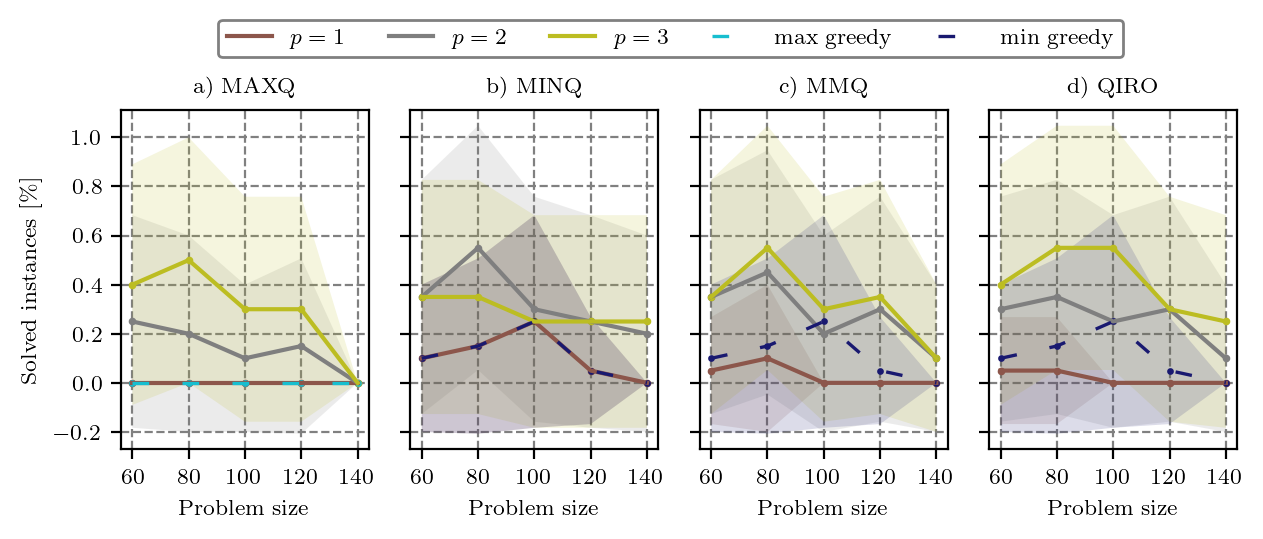

In [77]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
ps = [1, 2, 3]
runs = list(range(20))
variations = ['MAXQ', 'MINQ', 'MMQ', 'QIRO']
iterations = [0]
version = 4
ns = [60, 80, 100, 120, 140]#, 160]

major_yticks_pos = [0.8, 0.9, 0.95, 0.99]
major_yticks_names = [0.8, 0.9, 0.95, 0.99]
major_yticks_names_2 = [None for _ in range(len(major_yticks_pos))]
minor_yticks_pos = [0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.91, 0.92, 0.93, 0.94, 0.96, 0.97, 0.98]
minor_ticks_names = [None for _ in range(len(minor_yticks_pos))]

recalc_intervals = [1, 2, 10, 50, 100]
methods = [f'cycle+rec{i}' for i in recalc_intervals]+['cycle']
# labels = ['rec. interv. 1', 'rec. interv. 2','rec. interv. 5','rec. interv. 10','rec. interv. 50','rec. interv. $\infty$']
labels = ['$p = 1$', '$p = 2$', '$p = 3$', 'min greedy', 'max greedy']
fig, axs = plt.subplots(1, 4, dpi=200, layout='tight', figsize=(1.9 * 3.35, 1.3* 9 * 3.35 / 16), sharey='row')


for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
        
        mean, error = get_percental_results(variations[idx], p, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1

    if idx ==0:
        counter +=1
        mean, error = get_percental_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
    else:
        mean, error = get_percental_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
    
        mean, error = get_percental_results(variations[idx], p, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=3, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle='solid', linewidth=1.5, label=labels[counter], color=colors[counter+6])
        counter +=1
    
    if idx==0:
        counter +=1
        mean, error = get_percental_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=1.2, label=labels[counter], color=colors[counter+6])
        counter +=1
    else:
        mean, error = get_percental_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=1.2, label=labels[counter], color=colors[counter+6])
        counter +=1

for ax in axs:
    ax.set_xlabel('Problem size')
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    ax.set_axisbelow(True)
    ax.set_xticks(ns, ns)
   #ax.set_yscale('logit')
    #ax.set_ylim(bottom=0.79, top=0.995)

axs[0].set_ylabel('Solved instances [$\%$]')
#ax1.set_xticks(range(1, 17, 2), np.round(np.linspace(0.1, 0.80, 8), 2))
#ax1.set_xticks()
# ax1.set_yscale('logit')
axs[0].set_title('a) MAXQ', loc='center')
axs[1].set_title('b) MINQ', loc='center')
axs[2].set_title('c) MMQ', loc='center')
axs[3].set_title('d) QIRO', loc='center')
# #ax1.gca()
# ax1.yaxis.set_ticklabels([])
# ax1.set_ylim(bottom=0.79, top=0.9997)
#axs[0].set_yticks(major_yticks_pos, major_yticks_names)
#axs[0].set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)

plt.tight_layout()
lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = axs[1].get_legend_handles_labels()
lines.append(lines2[-1])
labels.append(labels2[-1])
axs[1].legend(lines, labels, loc='upper center', ncols=6, bbox_to_anchor=(1.05, 1.3), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)
#fig.savefig('./plots/appr_vs_density_log_gurobi_std_80_graphs_missing_errors.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Log

/Users/Q642074/miniconda3/envs/qiro/lib/python3.9/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/Q642074/miniconda3/envs/qiro/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Q642074/miniconda3/envs/qiro/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Q642074/miniconda3/envs/qiro/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Q642074/miniconda3/envs/qiro/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


is happening
is happening
is happening


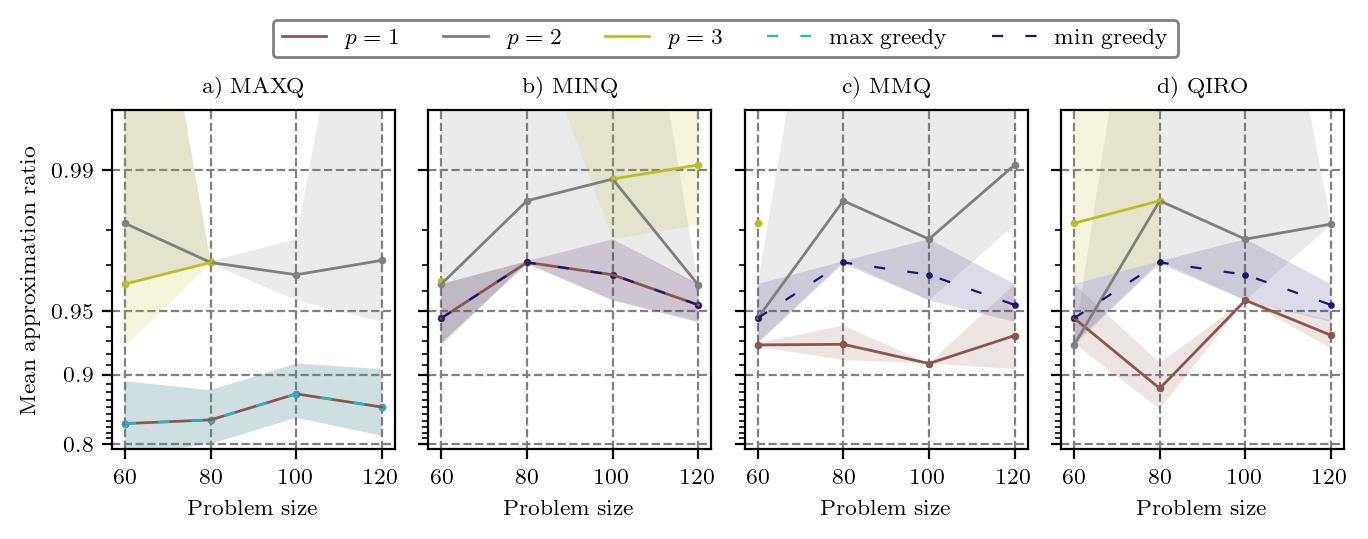

In [35]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
ps = [1, 2, 3]
runs = list(range(2))
variations = ['MAXQ', 'MINQ', 'MMQ', 'QIRO']
iterations = [0]
version = 3
ns = [60, 80, 100, 120]

major_yticks_pos = [0.8, 0.9, 0.95, 0.99]
major_yticks_names = [0.8, 0.9, 0.95, 0.99]
major_yticks_names_2 = [None for _ in range(len(major_yticks_pos))]
minor_yticks_pos = [0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.91, 0.92, 0.93, 0.94, 0.96, 0.97, 0.98]
minor_ticks_names = [None for _ in range(len(minor_yticks_pos))]

instances = [f'density{round(density,2)}_id{k}' for density in densities for k in range(10)]
recalc_intervals = [1, 2, 10, 50, 100]
methods = [f'cycle+rec{i}' for i in recalc_intervals]+['cycle']
# labels = ['rec. interv. 1', 'rec. interv. 2','rec. interv. 5','rec. interv. 10','rec. interv. 50','rec. interv. $\infty$']
labels = ['$p = 1$', '$p = 2$', '$p = 3$', 'min greedy', 'max greedy']
fig, axs = plt.subplots(1, 4, dpi=200, layout='tight', figsize=(1.9 * 3.35, 1.3* 9 * 3.35 / 16), sharey='row')


for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
        
        mean, error = get_results(variations[idx], p, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1

    if idx ==0:
        counter +=1
        mean, error = get_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
    else:
        mean, error = get_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.fill_between(ns, error_min, error_max, alpha = 0.15, color = colors[counter+6], edgecolor = None)
        counter +=1
for idx, ax in enumerate(axs): 
    counter = 0
    for p in ps: 
    
        mean, error = get_results(variations[idx], p, runs, ns, iterations, version)
        mean = mean
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=3, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle='solid', linewidth=1, label=labels[counter], color=colors[counter+6])
        counter +=1
    
    if idx==0:
        counter +=1
        mean, error = get_results('max_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=0.8, label=labels[counter], color=colors[counter+6])
        counter +=1
    else:
        print('is happening')
        mean, error = get_results('min_greedy', 1, runs, ns, iterations, version)
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j if i+j <1 else 0.9999 for i, j in zip(mean, error)]
        ax.scatter(ns, mean, s=2, label='_nolegend_', color=colors[counter+6])
        ax.plot(ns, mean, linestyle=(0, (5, 10)), linewidth=0.8, label=labels[counter], color=colors[counter+6])
        counter +=1

for ax in axs:
    ax.set_xlabel('Problem size')
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    ax.set_axisbelow(True)
    ax.set_yscale('logit')
    ax.set_ylim(bottom=0.79, top=0.995)



axs[0].set_ylabel('Mean approximation ratio')
#ax1.set_xticks(range(1, 17, 2), np.round(np.linspace(0.1, 0.80, 8), 2))
# ax1.set_xticks(range(1, 18, 2), [0.1, None, 0.3, None, 0.5, None, 0.7, None, 0.9])
# ax1.set_yscale('logit')
axs[0].set_title('a) MAXQ', loc='center')
axs[1].set_title('b) MINQ', loc='center')
axs[2].set_title('c) MMQ', loc='center')
axs[3].set_title('d) QIRO', loc='center')
# #ax1.gca()
# ax1.yaxis.set_ticklabels([])
# ax1.set_ylim(bottom=0.79, top=0.9997)
axs[0].set_yticks(major_yticks_pos, major_yticks_names)
axs[0].set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)

plt.tight_layout()
lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = axs[1].get_legend_handles_labels()
lines.append(lines2[-1])
labels.append(labels2[-1])
axs[1].legend(lines, labels, loc='upper center', ncols=6, bbox_to_anchor=(1.05, 1.3), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)
#fig.savefig('./plots/appr_vs_density_log_gurobi_std_80_graphs_missing_errors.pdf', dpi=300, bbox_inches='tight')
plt.show()